In [ ]:
# States for Graphs apart from being of TypedDict, can also be @dataclass(Dataclasses) and BaseModel(Pydantic)

In [5]:
from langchain_google_genai import ChatGoogleGenerativeAI

In [3]:
from langchain_groq import ChatGroq

In [12]:
from dataclasses import dataclass
from pydantic import BaseModel, field_validator
from typing import Literal, TypedDict

@dataclass
class DataClassState:
    name: str
    mood: Literal["happy", "sad"]

# Pydantic models are mainly used for input validations to catch ValueErrors early.
class PydanticState(BaseModel):
    name: str
    mood: Literal["happy", "sad"]

    @field_validator("mood")
    @classmethod
    def check_mood(cls, value):
        if value != Literal["happy", "sad"]:
            raise ValueError("mood can only be happy or sad")
        else: 
            return value

class State(TypedDict):
    name: str
    mood: Literal["happy", "sad"]

In [ ]:
# Now whenenver you use these models for typedDict States you can use state["name"]
# for pydantic and dataclass you can state.name


In [ ]:
# when you are working with different nodes and want to store the updates at each node being done to the state variable.
# use Annotated[] typing for the variable you are using. 
# Here comes the stateReducer concept, which let's you use custom functions or already available functions to concatenate values into the state variable.
# StateReducers are simply functions working on your state


#eg: For adding

from langgraph.graph.message import add_messages, RemoveMessage
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage
from typing import Annotated, List, TypedDict

class State(TypedDict):
    messages: Annotated[List[AnyMessage], add_messages]
    # with some arbitrary keys.

messages = [
    HumanMessage(content = "hey, how are you?")
]

print(add_messages(messages, AIMessage("Hey, I am good. What about you??")))
print("\n")
# Treats 2nd argument as a HumanMessage
print(add_messages(messages, "I am good."))

[HumanMessage(content='hey, how are you?', additional_kwargs={}, response_metadata={}, id='fb88bc26-b162-4986-b188-19abfe3b04cc'), AIMessage(content='Hey, I am good. What about you??', additional_kwargs={}, response_metadata={}, id='80dd646f-fce5-42b6-93cf-33d14e085fbc', tool_calls=[], invalid_tool_calls=[])]


[HumanMessage(content='hey, how are you?', additional_kwargs={}, response_metadata={}, id='fb88bc26-b162-4986-b188-19abfe3b04cc'), HumanMessage(content='I am good.', additional_kwargs={}, response_metadata={}, id='84b62d89-38ee-4140-8dcf-05e6875d91b5')]


In [ ]:
# for rewriting

messages = [
    HumanMessage(content = "Hey I am Harsh", name = "Harsh", id = 1),
    AIMessage(content = "Hey Harsh. How are you doing?", name = "Groq", id = 2)
]

updated_message_1 = HumanMessage(content = "Hey, I am Nancy", name = "Nancy", id = 1) # ----> trying with same id = 1 
updated_message_2 = HumanMessage(content = "Hey, I am Harsh", name = "Nancy", id = 3)

print(add_messages(messages, updated_message_1))
print(add_messages(messages, updated_message_2))

[HumanMessage(content='Hey, I am Nancy', additional_kwargs={}, response_metadata={}, name='Nancy', id='1'), AIMessage(content='Hey Harsh. How are you doing?', additional_kwargs={}, response_metadata={}, name='Groq', id='2', tool_calls=[], invalid_tool_calls=[])]
[HumanMessage(content='Hey I am Harsh', additional_kwargs={}, response_metadata={}, name='Harsh', id='1'), AIMessage(content='Hey Harsh. How are you doing?', additional_kwargs={}, response_metadata={}, name='Groq', id='2', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='Hey, I am Harsh', additional_kwargs={}, response_metadata={}, name='Nancy', id='3')]


In [35]:
# You can use the above method to store the updates at each node of the graph.
# When you want to delete some of that updates you can use RemoveMessage

# use it like given below
# for removing messages too you can use add_messages like below

messages = add_messages(messages, updated_message_2)
print(messages[0].id)

deleted_messages = [RemoveMessage(id = m.id) for m in messages[: -2]]
print(deleted_messages)

# when you do add_messages with deleted_messages and messages, you get...
add_messages(messages, deleted_messages) # ---> a list of messages where messages before a certain point are deleted.


1
[RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='1')]


[AIMessage(content='Hey Harsh. How are you doing?', additional_kwargs={}, response_metadata={}, name='Groq', id='2', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Hey, I am Harsh', additional_kwargs={}, response_metadata={}, name='Nancy', id='3')]

In [ ]:
# You can even use multiple schema for your graph where you have
# a schema for input, a schema for output and a schema for storing overall information

# eg:

from langgraph import StateGraph

class PrivateState(TypedDict):
    pass

class OverallState(TypedDict):
    pass

def node1(OverallState)-> PrivateState:
    pass

# node1 and node2 share Private State, one gives it as the output and other takes it as the input.
def node2(PrivateState)-> OverallState:
    pass

builder = StateGraph(OverallState)
# Node Creation, Edge creation, etc.
builder.add_edge(node1, node2)
# ending edge.


C:\Users\HarshMaheshAgrawal\AppData\Local\Temp\ipykernel_2728\2965340868.py:36: LangGraphDeprecatedSinceV05: `input` is deprecated and will be removed. Please use `input_schema` instead. Deprecated in LangGraph V0.5 to be removed in V2.0.
  builder = StateGraph(OverallState, input = InputState, output = OutputState)
C:\Users\HarshMaheshAgrawal\AppData\Local\Temp\ipykernel_2728\2965340868.py:36: LangGraphDeprecatedSinceV05: `output` is deprecated and will be removed. Please use `output_schema` instead. Deprecated in LangGraph V0.5 to be removed in V2.0.
  builder = StateGraph(OverallState, input = InputState, output = OutputState)


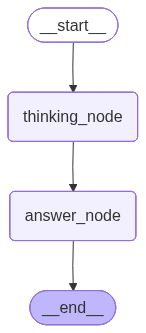

In [40]:
# you can also pass custom states for input and output inside the StateGraph.

from langgraph.graph import StateGraph, START, END

class InputState(TypedDict):
    question: str

class OutputState(TypedDict):
    answer: str

class OverallState(TypedDict):
    question: str
    answer: str
    notes: str


def thinking_node(InputState):
    return {'answer': "Bye", "note": "... name is Elisa."}

def answer_node(OverallState)-> OutputState:
    return {"answer": "Bye Elisa!"}


# Invocation Flow

# Input: {"question": "Can I leave?"} (InputState)
#   ↓
# thinking_node() → returns {'answer': "Bye", "note": "..."}
#   ↓
# OverallState updated with all fields
#   ↓
# answer_node() → receives full OverallState, returns OutputState
#   ↓
# Output filtered to: {"answer": "Bye Elisa!"} (OutputState only)

builder = StateGraph(OverallState, input = InputState, output = OutputState)

builder.add_node("thinking_node", thinking_node)
builder.add_node("answer_node", answer_node)

builder.add_edge(START, "thinking_node")
builder.add_edge("thinking_node", "answer_node")
builder.add_edge("answer_node", END)

graph = builder.compile()
graph.invoke({"question": "Can I leave?"})

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage
llm = ChatGoogleGenerativeAI(model = "gemini-flash-latest")
llm.invoke([HumanMessage(content = "What is the date today?")])
llm.invoke("What is the date today?")

AIMessage(content=[{'type': 'text', 'text': 'Today is Friday, February 14, 2025.', 'extras': {'signature': 'EtIKCs8KAQw51sexAVfWTBo2JbSAspe8EtChiGJmIbIgEGswIcMMXD3ZV0pGIhimzmgTGn71rZNWalymDaRYG6fq321Br3YWZssxtFe51jur3PifPmNbLxBDjhgP13Cd2oJJnM+HncGPBNn9AcEFAfkKKnOHWHjcIvtifWaprQuFWPjz38+oBpjJvKYC1OV6Fa+h9498x65Z7Y7+2u2Gz2PjvgsMuk+gcteMt0LfZomhbazC95PeePuMqUX1M68qrzborzzBiLTFYHU7uy6CBHYNR0h9VKApmJNHnvmeukGATXA/yoer0qVQspfrW1f8txIHBqAca/Fkr8bsw9YkJpXQLTJutZBfxNB9ZWloHZ9A6vVYAcyA43njMR/H/OQNJJapWUYQeKgrJIMTa6OtfcMHVN3Ji+0rJvAh4vKK+e/fqifEKLD4eTfkO+a18z/dzvONy6M1l28Nc5m0nfvgPwHOXhFHcrdq6yTLfVbwiBaMzJC2+8qssJ5wk/rHiWoWGI0fn4G9bivklOOzZhpKxeKFdKtKY7gwzj9cRt5CC35Mltwp2YHkcDcdGcjlLNJ6pQcVJfl9uophsuww41ULBZA1kYYK3KZZAo5K44bW/tqvwfHnUejtmx6sSCoB6ycz0KmjgIb6/LaZ2ct1dYFhMzKXVnmsmu7nqDCuKwAYVjhi1UiongD88Msa4rejoqDz9K0HKSoLCifj98fLPSBCWWqA42B2w5wQTxKHSnu0lzN/6ASqz4JsIn+nwy5jPbJY4r355b1SWwJ39iS4pv5utzEO6iu09q5z5YcCQG5/hTUx9yhUuX0xy+dfDQgh4oprGCTcKhYINHBuCdD7DxyFxNjLZpqWIUMqX2xHmwag28eZCZxhryazgfvOVmGG